In [1]:
### Importation des modules 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn import decomposition




In [2]:
data_true = pd.read_csv("data.csv")
print(data_true.head())
print(data_true.shape)

  Catalog  HIP Proxy        RAhms        DEdms  Vmag  VarFlag r_Vmag  \
0       H    1   NaN  00 00 00.22  +01 05 20.4  9.10      NaN      H   
1       H    2   NaN  00 00 00.91  -19 29 55.8  9.27      NaN      G   
2       H    3   NaN  00 00 01.20  +38 51 33.4  6.61      NaN      G   
3       H    4   NaN  00 00 02.01  -51 53 36.8  8.06      NaN      H   
4       H    5   NaN  00 00 02.39  -40 35 28.4  8.55      NaN      H   

      RAdeg      DEdeg  ... Survey  Chart  Notes        HD         BD  \
0  0.000912   1.089013  ...      S    NaN    NaN  224700.0  B+00 5077   
1  0.003797 -19.498837  ...    NaN    NaN    NaN  224690.0  B-20 6688   
2  0.005008  38.859286  ...      S    NaN    NaN  224699.0  B+38 5108   
3  0.008382 -51.893546  ...      S    NaN    NaN  224707.0        NaN   
4  0.009965 -40.591224  ...    NaN    NaN    NaN  224705.0        NaN   

          CoD         CPD  (V-I)red  SpType  r_SpType  
0         NaN         NaN      0.66      F5         S  
1         NaN   

In [3]:
# copie de data
data = data_true.copy()

# Filtrer les étoiles avec une parallaxe positive et significative
data = data[data['Plx'] > 0]

# Calcul de la distance (en pc) 
data['Distance'] = 1/data['Plx'] * 1000  

# Calcul de la magnitude absolue 
data['AbsoluteMag'] = data['Vmag'] - 5 * np.log10(data['Distance'] / 10)   

# Fonction pour calculer la température effective des étoiles
def bv_to_temp(bv):
    return 4600 * ((1 / (0.92 * bv + 1.7)) + (1 / (0.92 * bv + 0.62)))

# Ajouter la température aux données
data['Temperature'] = bv_to_temp(data['B-V'])


In [4]:
colonnes_inutiles = [
    "Catalog", "Proxy", "VarFlag", "AstroRef", "m_BTmag", "CombMag",
    "m_Hpmag", "Period", "HvarType", "moreVar", "morePhoto", "CCDM", "n_CCDM",
    "Nsys", "MultFlag", "Source", "Qual", "m_HIP", "theta", "rho", "e_rho",
    "dHp", "e_dHp", "Survey", "Chart", "Notes", "HD", "BD", "CoD", "CPD"
]
data_pca = data.drop(columns=colonnes_inutiles)
data_pca

,HIP,RAhms,DEdms,Vmag,r_Vmag,RAdeg,DEdeg,Plx,pmRA,pmDE,...,o_Hpmag,Hpmax,HPmin,Ncomp,(V-I)red,SpType,r_SpType,Distance,AbsoluteMag,Temperature
0,1,00 00 00.22,+01 05 20.4,9.10,H,0.000912,1.089013,3.54,-5.20,-1.88,...,87.0,9.17,9.24,1.0,0.66,F5,S,282.485876,1.845016,6471.667826
1,2,00 00 00.91,-19 29 55.8,9.27,G,0.003797,-19.498837,21.90,181.21,-0.93,...,120.0,9.37,9.44,1.0,1.04,K3V,4,45.662100,5.972221,4745.140425
2,3,00 00 01.20,+38 51 33.4,6.61,G,0.005008,38.859286,2.81,5.24,-2.91,...,127.0,6.60,6.62,1.0,0.00,B9,S,355.871886,-1.146468,10368.595588
3,4,00 00 02.01,-51 53 36.8,8.06,H,0.008382,-51.893546,7.75,62.85,0.16,...,201.0,8.12,8.18,1.0,0.43,F0V,2,129.032258,2.506509,7044.130880
4,5,00 00 02.39,-40 35 28.4,8.55,H,0.009965,-40.591224,2.87,2.53,9.07,...,161.0,8.68,8.74,1.0,0.95,G8III,2,348.432056,0.839409,4991.060700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118213,118318,23 59 51.30,+11 40 25.4,6.99,H,359.963744,11.673709,1.92,-2.16,2.09,...,92.0,7.08,7.12,1.0,1.56,K2,S,520.833333,-1.593494,3655.993639
118214,118319,23 59 53.74,-22 25 41.4,8.23,G,359.973913,-22.428180,10.63,148.74,27.53,...,118.0,8.34,8.39,1.0,0.70,G2V,4,94.073377,3.362666,5818.920292
118215,118320,23 59 54.25,+05 57 23.9,7.59,H,359.976057,5.956638,5.00,20.92,-35.26,...,86.0,7.74,7.77,1.0,0.98,K0,S,200.000000,1.084850,4745.140425
118216,118321,23 59 54.78,-64 22 21.3,9.20,G,359.978239,-64.372572,19.22,216.99,106.46,...,145.0,9.28,9.36,1.0,0.75,G5V,1,52.029136,5.618767,5608.544902


In [5]:
data_clean_pca = data_pca.dropna(axis=0)
data_clean_pca.shape


(107777, 51)

In [6]:
data_clean_pca.dtypes

HIP              int64
RAhms           object
DEdms           object
Vmag           float64
r_Vmag          object
RAdeg          float64
DEdeg          float64
Plx            float64
pmRA           float64
pmDE           float64
e_RAdeg        float64
e_DEdeg        float64
e_Plx          float64
e_pmRA         float64
e_pmDE         float64
DE:RA          float64
Plx:RA         float64
Plx:DE         float64
pmRA:RA        float64
pmRA:DE        float64
pmRA:Plx       float64
pmDE:RA        float64
pmDE:DE        float64
pmDE:Plx       float64
pmDE:pmRA      float64
F1             float64
F2             float64
---              int64
BTmag          float64
e_BTmag        float64
VTmag          float64
e_VTmag        float64
B-V            float64
e_B-V          float64
r_B-V           object
V-I            float64
e_V-I          float64
r_V-I           object
Hpmag          float64
e_Hpmag        float64
Hpscat         float64
o_Hpmag        float64
Hpmax          float64
HPmin      

In [7]:
non_float_cols = data_clean_pca.select_dtypes(exclude=['float']).columns
print(non_float_cols)


Index(['HIP', 'RAhms', 'DEdms', 'r_Vmag', '---', 'r_B-V', 'r_V-I', 'SpType',
       'r_SpType'],
      dtype='object')


In [8]:
data_clean_pca_2 = data_clean_pca.drop(columns='---')
print(data_clean_pca_2.dtypes)
data_clean_pca_2


HIP              int64
RAhms           object
DEdms           object
Vmag           float64
r_Vmag          object
RAdeg          float64
DEdeg          float64
Plx            float64
pmRA           float64
pmDE           float64
e_RAdeg        float64
e_DEdeg        float64
e_Plx          float64
e_pmRA         float64
e_pmDE         float64
DE:RA          float64
Plx:RA         float64
Plx:DE         float64
pmRA:RA        float64
pmRA:DE        float64
pmRA:Plx       float64
pmDE:RA        float64
pmDE:DE        float64
pmDE:Plx       float64
pmDE:pmRA      float64
F1             float64
F2             float64
BTmag          float64
e_BTmag        float64
VTmag          float64
e_VTmag        float64
B-V            float64
e_B-V          float64
r_B-V           object
V-I            float64
e_V-I          float64
r_V-I           object
Hpmag          float64
e_Hpmag        float64
Hpscat         float64
o_Hpmag        float64
Hpmax          float64
HPmin          float64
Ncomp      

,HIP,RAhms,DEdms,Vmag,r_Vmag,RAdeg,DEdeg,Plx,pmRA,pmDE,...,o_Hpmag,Hpmax,HPmin,Ncomp,(V-I)red,SpType,r_SpType,Distance,AbsoluteMag,Temperature
0,1,00 00 00.22,+01 05 20.4,9.10,H,0.000912,1.089013,3.54,-5.20,-1.88,...,87.0,9.17,9.24,1.0,0.66,F5,S,282.485876,1.845016,6471.667826
1,2,00 00 00.91,-19 29 55.8,9.27,G,0.003797,-19.498837,21.90,181.21,-0.93,...,120.0,9.37,9.44,1.0,1.04,K3V,4,45.662100,5.972221,4745.140425
2,3,00 00 01.20,+38 51 33.4,6.61,G,0.005008,38.859286,2.81,5.24,-2.91,...,127.0,6.60,6.62,1.0,0.00,B9,S,355.871886,-1.146468,10368.595588
3,4,00 00 02.01,-51 53 36.8,8.06,H,0.008382,-51.893546,7.75,62.85,0.16,...,201.0,8.12,8.18,1.0,0.43,F0V,2,129.032258,2.506509,7044.130880
4,5,00 00 02.39,-40 35 28.4,8.55,H,0.009965,-40.591224,2.87,2.53,9.07,...,161.0,8.68,8.74,1.0,0.95,G8III,2,348.432056,0.839409,4991.060700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118213,118318,23 59 51.30,+11 40 25.4,6.99,H,359.963744,11.673709,1.92,-2.16,2.09,...,92.0,7.08,7.12,1.0,1.56,K2,S,520.833333,-1.593494,3655.993639
118214,118319,23 59 53.74,-22 25 41.4,8.23,G,359.973913,-22.428180,10.63,148.74,27.53,...,118.0,8.34,8.39,1.0,0.70,G2V,4,94.073377,3.362666,5818.920292
118215,118320,23 59 54.25,+05 57 23.9,7.59,H,359.976057,5.956638,5.00,20.92,-35.26,...,86.0,7.74,7.77,1.0,0.98,K0,S,200.000000,1.084850,4745.140425
118216,118321,23 59 54.78,-64 22 21.3,9.20,G,359.978239,-64.372572,19.22,216.99,106.46,...,145.0,9.28,9.36,1.0,0.75,G5V,1,52.029136,5.618767,5608.544902


In [9]:
cols_encoder = ["RAhms", "DEdms", "r_Vmag", "r_B-V", "r_V-I", "SpType", "r_SpType"]
label_encoders = {}

for col in cols_encoder:
    if col in data_clean_pca_2.columns:
        le = LabelEncoder()
        data_clean_pca_2[col] = le.fit_transform(data_clean_pca_2[col].astype(str))
        label_encoders[col] = le
    else:
        print(f"⚠️ Colonne '{col}' non trouvée dans le DataFrame")

data_clean_pca_2
print(data_clean_pca_2.dtypes)

HIP              int64
RAhms            int64
DEdms            int64
Vmag           float64
r_Vmag           int64
RAdeg          float64
DEdeg          float64
Plx            float64
pmRA           float64
pmDE           float64
e_RAdeg        float64
e_DEdeg        float64
e_Plx          float64
e_pmRA         float64
e_pmDE         float64
DE:RA          float64
Plx:RA         float64
Plx:DE         float64
pmRA:RA        float64
pmRA:DE        float64
pmRA:Plx       float64
pmDE:RA        float64
pmDE:DE        float64
pmDE:Plx       float64
pmDE:pmRA      float64
F1             float64
F2             float64
BTmag          float64
e_BTmag        float64
VTmag          float64
e_VTmag        float64
B-V            float64
e_B-V          float64
r_B-V            int64
V-I            float64
e_V-I          float64
r_V-I            int64
Hpmag          float64
e_Hpmag        float64
Hpscat         float64
o_Hpmag        float64
Hpmax          float64
HPmin          float64
Ncomp      

In [10]:


# Étape 2 : extraire HIP seulement après
hip_array = data_clean_pca_2['HIP'].values

# Étape 3 : retirer HIP pour la PCA
data_pca_ready = data_clean_pca_2.drop(columns='HIP')

In [11]:
pca = decomposition.PCA(n_components=2) # 2 pour garder 2 composantes
pca.fit(data_pca_ready)
#print("Avant : (les 10 premiers éléments seuls)\n", data_clean_pca_2[:10,:])

data_t = pca.transform(data_pca_ready)
print("Dimension de data_t :", data_t.shape)
print("Après : (les 10 premiers éléments seult)\n", data_t[:10,:])

data_t_df = pd.DataFrame(data_t, columns=['Col1', 'Col2'])


Dimension de data_t : (107777, 2)
Après : (les 10 premiers éléments seult)
 [[ 58172.50081573 -47270.17420376]
 [ 52108.92285417  17791.28230567]
 [ 55420.51550016 -17698.29939989]
 [ 49684.20171525  43833.87896086]
 [ 50547.5399389   34525.99312396]
 [ 56767.60903471 -32254.79996392]
 [ 56334.38652123 -27630.81271204]
 [ 55567.21804831 -19400.5500138 ]
 [ 49754.47335386  43017.17659747]
 [ 54853.79555674 -11699.58117048]]


In [12]:
# Séparation en train/validation/test
X_train, X_temp = train_test_split(data_t_df, test_size=0.3, random_state=0)
X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=0)

print(f"Taille du train : {X_train.shape}")
print(f"Taille du validation : {X_val.shape}")
print(f"Taille du test : {X_test.shape}")
print(type(X_train))

Taille du train : (75443, 2)
Taille du validation : (16167, 2)
Taille du test : (16167, 2)
<class 'pandas.core.frame.DataFrame'>


In [13]:
print(X_train.isnull().sum())

Col1    0
Col2    0
dtype: int64


In [14]:
# Entraînement du modèle k=4
kmeans = KMeans(n_clusters=4, random_state=0)
kmeans.fit(X_train)

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=4, random_state=0)

In [15]:
print("Centres des clusters :")
print(kmeans.cluster_centers_) 

Centres des clusters :
[[ 29724.05350094 -24372.04050071]
 [-27808.62915162  25229.46909329]
 [-25486.18861404 -29087.41187775]
 [ 23941.25768078  27783.796769  ]]


In [16]:
# Prédire les clusters pour l'ensemble d'entraînement
train_clusters = kmeans.predict(X_train)

# Ajouter les clusters comme une nouvelle colonne dans X_train
X_train['Cluster'] = train_clusters
X_train

,Col1,Col2,Cluster
17368,36838.130812,-4235.565024,0
37163,16637.997009,642.224374,3
91427,-34140.209957,-35699.016938,2
37339,18920.347958,-25726.136745,0
13392,44992.758850,-49202.096852,0
...,...,...,...
21243,36661.591965,-43932.701862,0
45891,6957.353694,11136.478785,3
42613,11696.564212,-4597.818859,0
43567,12119.713661,-19407.982785,0


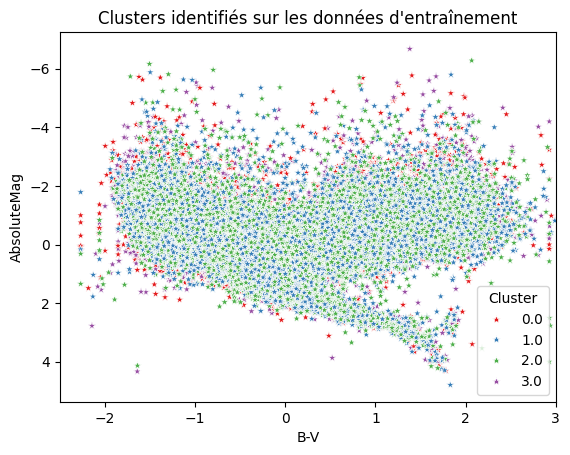

In [17]:



"""scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_pca_ready)
X_scaled_df = pd.DataFrame(X_scaled, columns = data_pca_ready.columns)"""

# Séparer la colonne 'HIP' des autres données
hip_column = data_clean_pca_2[['HIP']]  # garde le DataFrame pour fusion facile
features_to_scale = data_clean_pca_2.drop(columns=['HIP'])

# Appliquer la normalisation uniquement sur les autres colonnes
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_to_scale)

# Recréer un DataFrame avec les colonnes d'origine (sauf HIP)
scaled_features_df = pd.DataFrame(scaled_features, columns=features_to_scale.columns, index=data_pca_ready.index)

# Réassembler les données avec la colonne 'HIP'
X_scaled_df = pd.concat([hip_column, scaled_features_df], axis=1)

filtered_data = X_scaled_df[X_scaled_df['HIP'].isin(hip_array)]

sns.scatterplot(x=filtered_data['B-V'], y=filtered_data['AbsoluteMag'], hue=X_train['Cluster'], palette="Set1", marker="*")   
plt.title("Clusters identifiés sur les données d'entraînement")
plt.xlim(-2.5, 3)
plt.gca().invert_yaxis()  # il faut inverser l'axe de AbsoluteMag par convention du diagramme HR
plt.show()

# bon graphe mais pas bons clusters 
# pb on ne voit pas distinctement les clusters : faire pca avec 2 ou 3 comp

In [18]:
def try_pca(n_components, n_clusters, X=data_pca_ready):
    print(f"n_components = {n_components}")
    print(f"n_clusters = {n_clusters}")
    pca = decomposition.PCA(n_components=n_components) # 2 pour garder 2 composantes
    pca.fit(X)
    #print("Avant : (les 10 premiers éléments seuls)\n", data_clean_pca_2[:10,:])

    data_t = pca.transform(X)
    
    # Create column names dynamically based on n_components
    columns = [f'Col{i+1}' for i in range(n_components)]
    data_t_df = pd.DataFrame(data_t, columns=columns)
    
    # Séparation en train/validation/test
    X_train, X_temp = train_test_split(data_t_df, test_size=0.3, random_state=0)
    X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=0)
    
    # Entraînement du modèle k=4
    kmeans = KMeans(n_clusters=n_clusters, random_state=0)
    kmeans.fit(X_train)

    train_clusters = kmeans.predict(X_train)

    # Ajouter les clusters comme une nouvelle colonne dans X_train
    X_train['Cluster'] = train_clusters

    # Séparer la colonne 'HIP' des autres données
    hip_column = data_clean_pca_2[['HIP']]  # garde le DataFrame pour fusion facile
    features_to_scale = data_clean_pca_2.drop(columns=['HIP'])

    # Appliquer la normalisation uniquement sur les autres colonnes
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features_to_scale)

    # Recréer un DataFrame avec les colonnes d'origine (sauf HIP)
    scaled_features_df = pd.DataFrame(scaled_features, columns=features_to_scale.columns, index=data_pca_ready.index)

    # Réassembler les données avec la colonne 'HIP'
    X_scaled_df = pd.concat([hip_column, scaled_features_df], axis=1)

    filtered_data = X_scaled_df[X_scaled_df['HIP'].isin(hip_array)]

    sns.scatterplot(x=filtered_data['B-V'], y=filtered_data['AbsoluteMag'], hue=X_train['Cluster'], palette="Set1", marker="*")   
    plt.title("Clusters identifiés sur les données d'entraînement")
    plt.xlim(-2.5, 3)
    plt.gca().invert_yaxis()  # il faut inverser l'axe de AbsoluteMag par convention du diagramme HR
    plt.show()

n_components = 4
n_clusters = 4


/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


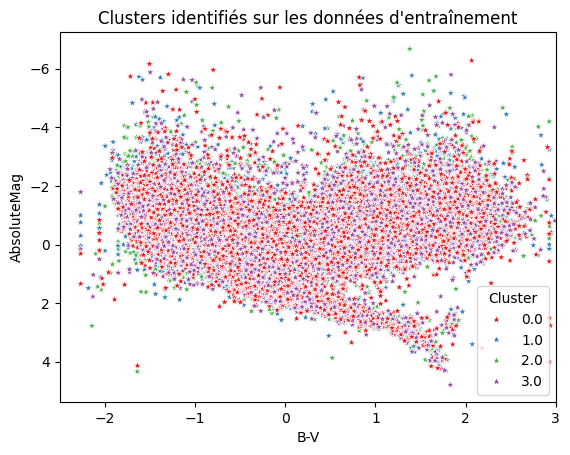

In [19]:
data_test = data_pca_ready.copy()
try_pca(4, 4, data_test)

n_components = 2
n_clusters = 4


/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


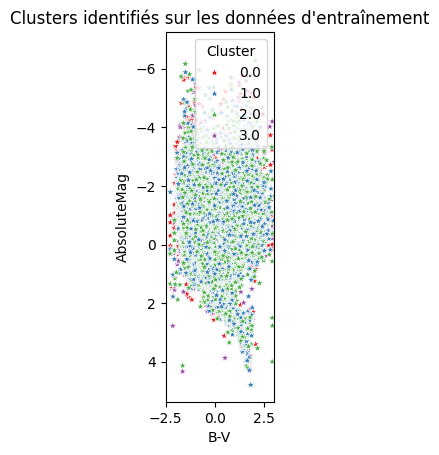

n_components = 3
n_clusters = 4


/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


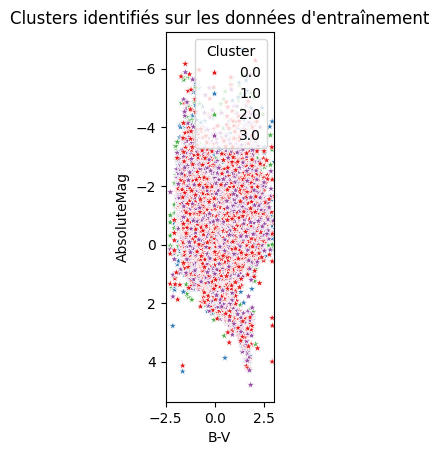

n_components = 4
n_clusters = 4


/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


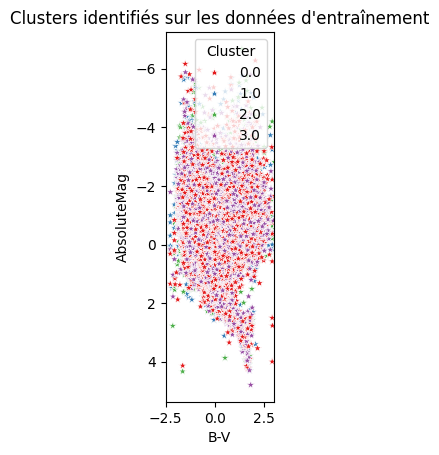

n_components = 5
n_clusters = 4


/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


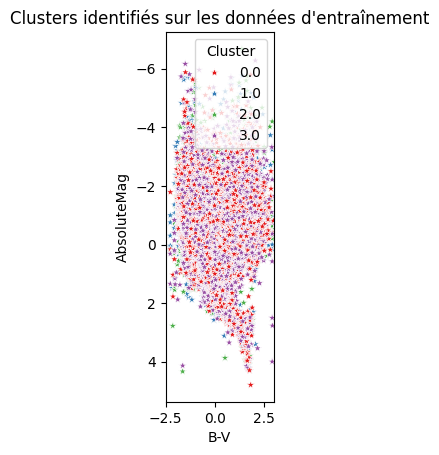

In [20]:
# Define range for components
n_components_range = range(2, 6)  # Test 2 to 5 components
n_clusters = 4  # Fixed number of clusters

data_test = data_pca_ready.copy()

# Create subplots for each number of components
for i, n_comp in enumerate(n_components_range):
    plt.subplot(1, len(n_components_range), i + 1)
    try_pca(n_comp, n_clusters, data_test)
